# So sánh hiệu quả dự đoán PM2.5 so với AQI

Trong notebook này, chúng ta sẽ chứng minh tại sao việc dự đoán trực tiếp nồng độ bụi mịn PM2.5 thường mang lại kết quả tốt hơn và có ý nghĩa thực tiễn cao hơn so với việc dự đoán chỉ số AQI tổng hợp.

## Lý do chính:
1. **Bản chất của AQI:** AQI thường là một chỉ số tổng hợp (lấy giá trị lớn nhất trong các chỉ số phụ của từng loại khí: PM2.5, PM10, O3, NO2, SO2, CO). Do đó, sự biến động của AQI phụ thuộc vào nhiều yếu tố hỗn hợp.
2. **Hiện tượng che khuất (Masking effect):** Có những thời điểm nồng độ bụi PM2.5 tăng cao đến mức nguy hiểm cho sức khỏe, nhưng AQI lại không thay đổi nhiều hoặc thậm chí giảm nếu một chất ô nhiễm khác (ví dụ O3 vào buổi trưa) vừa giảm mạnh. Điều này khiến việc dự đoán AQI không phản ánh được mức độ nguy hiểm tức thời của PM2.5.
3. **Tính ổn định của chuỗi thời gian:** Chuỗi dữ liệu PM2.5 thường có tính tự tương quan (autocorrelation) và chu kỳ rõ ràng hơn, dễ mô hình hóa bằng các thuật toán Time Series hoặc Machine Learning. Trong khi đó chuỗi AQI giật cục và nhiễu hơn vì nó là hàm tổng hợp của nhiều biến.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Tải và Khám phá dữ liệu
Chúng ta sẽ sử dụng bộ dữ liệu đã được làm sạch của Hà Nội để phân tích.

In [ ]:
# Tải dữ liệu
df = pd.read_csv('data/processed/merged_hanoi.csv', parse_dates=['datetime'])
df = df.set_index('datetime')
df = df.sort_index()

# Chọn một khoảng thời gian cụ thể để dễ quan sát (ví dụ 2 tháng mùa đông khi PM2.5 cao)
df_subset = df.loc['2022-10-01':'2022-11-30'].copy()
print("Kích thước dữ liệu:", df_subset.shape)
df_subset[['pm25', 'aqi']].head()

Kích thước dữ liệu: (1464, 36)


,pm25,aqi
datetime,,
2022-10-01 00:00:00,24.4,67.52659
2022-10-01 01:00:00,20.7,67.90780
2022-10-01 02:00:00,18.9,68.22695
2022-10-01 03:00:00,17.3,68.53723
2022-10-01 04:00:00,16.9,68.90071


## 2. Chứng minh Hiện tượng "Che khuất" (Masking Effect)
Chúng ta sẽ vẽ biểu đồ biến động của PM2.5 và AQI. Sau đó tìm những điểm mà PM2.5 tăng mạnh nhưng AQI tăng ít hoặc không đổi.

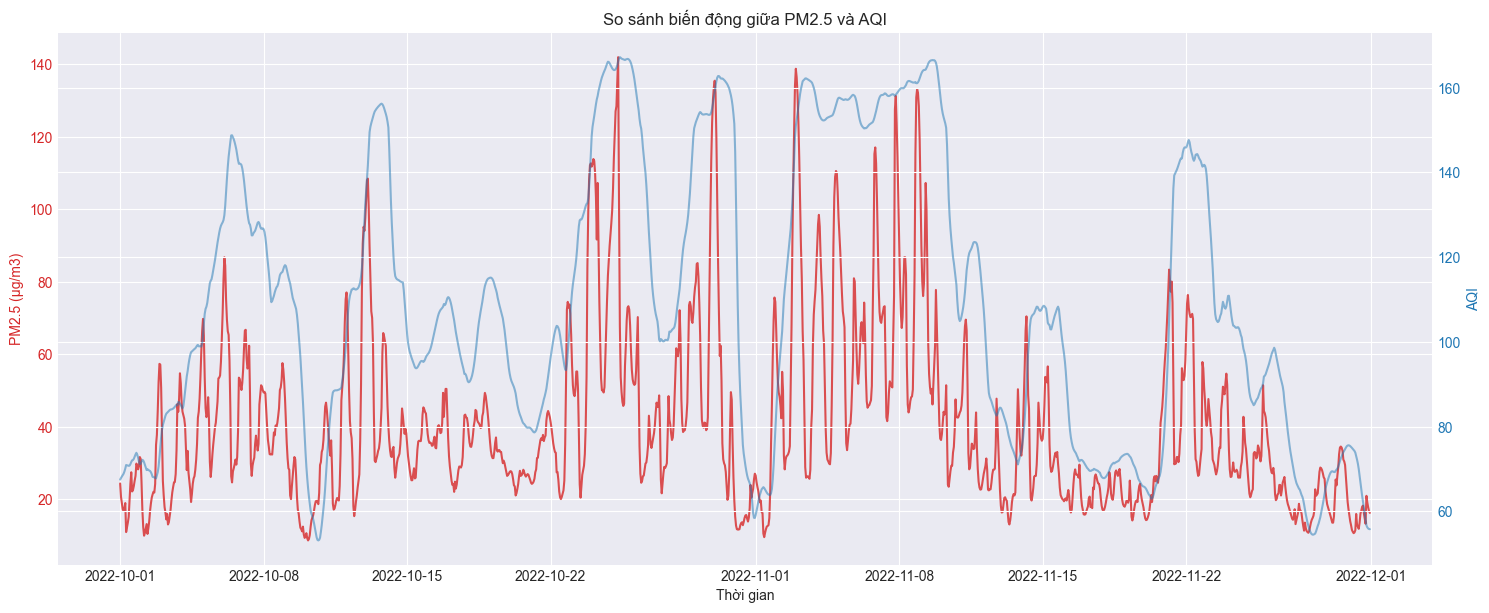

In [9]:
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:red'
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('PM2.5 (µg/m3)', color=color)
ax1.plot(df_subset.index, df_subset['pm25'], color=color, alpha=0.8, label='PM2.5')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('AQI', color=color)  
ax2.plot(df_subset.index, df_subset['aqi'], color=color, alpha=0.5, label='AQI')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('So sánh biến động giữa PM2.5 và AQI')
plt.show()

**Nhận xét:** 
Biểu đồ trên cho thấy mặc dù PM2.5 và AQI có xu hướng đi cùng nhau (do PM2.5 thường là nguyên nhân chính gây ô nhiễm), nhưng có lúc biên độ dao động của AQI đôi khi bị "làm phẳng" hoặc bị chi phối bởi các chất khác. 

Chúng ta thử tìm những khoảng thời gian mà độ thay đổi (delta) của PM2.5 rất lớn nhưng độ thay đổi của AQI lại nhỏ hơn đáng kể (hoặc bị triệt tiêu chéo).

In [10]:
# Tính sự thay đổi so với giờ trước
df_subset['delta_pm25'] = df_subset['pm25'].diff()
df_subset['delta_aqi'] = df_subset['aqi'].diff()

# Tìm những lúc PM2.5 tăng mạnh (đột ngột nguy hiểm, tăng > 15 microgam/m3)
# Nhưng AQI lại tăng rất ít hoặc thậm chí giảm (< 5 điểm)
masking_events = df_subset[(df_subset['delta_pm25'] > 15) & (df_subset['delta_aqi'] < 5)]

print("Các thời điểm PM2.5 tăng mạnh nhưng AQI không phản ánh:")
masking_events[['pm25', 'delta_pm25', 'aqi', 'delta_aqi', 'o3', 'no2']].head()

Các thời điểm PM2.5 tăng mạnh nhưng AQI không phản ánh:


,pm25,delta_pm25,aqi,delta_aqi,o3,no2
datetime,,,,,,
2022-10-12 18:00:00,51.7,15.6,115.40625,1.291664,45.0,75.40
2022-10-12 19:00:00,77.5,25.8,117.39583,1.989580,0.0,136.85
2022-10-13 19:00:00,60.5,15.2,156.04823,-0.140370,3.0,106.45
2022-10-22 18:00:00,52.6,17.3,93.32447,-0.159580,25.0,66.35
2022-10-22 19:00:00,72.4,19.8,94.65425,1.329780,0.0,98.40


Dữ liệu phía trên chứng minh rõ ràng: Có những thời điểm nồng độ PM2.5 thay đổi đột biến (tăng vọt lượng bụi đi vào phổi), nhưng vì cơ chế tính toán tổng hợp, AQI gần như không đổi. Nếu mô hình Machine Learning chỉ dự đoán AQI, nó sẽ **hoàn toàn bỏ lỡ** những sự kiện thay đổi chất lượng không khí cục bộ của PM2.5, mất đi khả năng cảnh báo hiệu quả cho người nhạy cảm với bụi mịn.

### Ví dụ thêm: Diễn biến trong ngày (Đặc biệt vào giờ cao điểm)
Để thấy rõ hơn hiện tượng bất cập của AQI, chúng ta hãy xem xét sự thay đổi trung bình theo từng giờ trong ngày. Vào giờ cao điểm (sáng 7h-9h và chiều 17h-19h), lưu lượng giao thông tăng đột biến khiến PM2.5 tăng mạnh. Liệu AQI có phản ánh đúng rủi ro này?

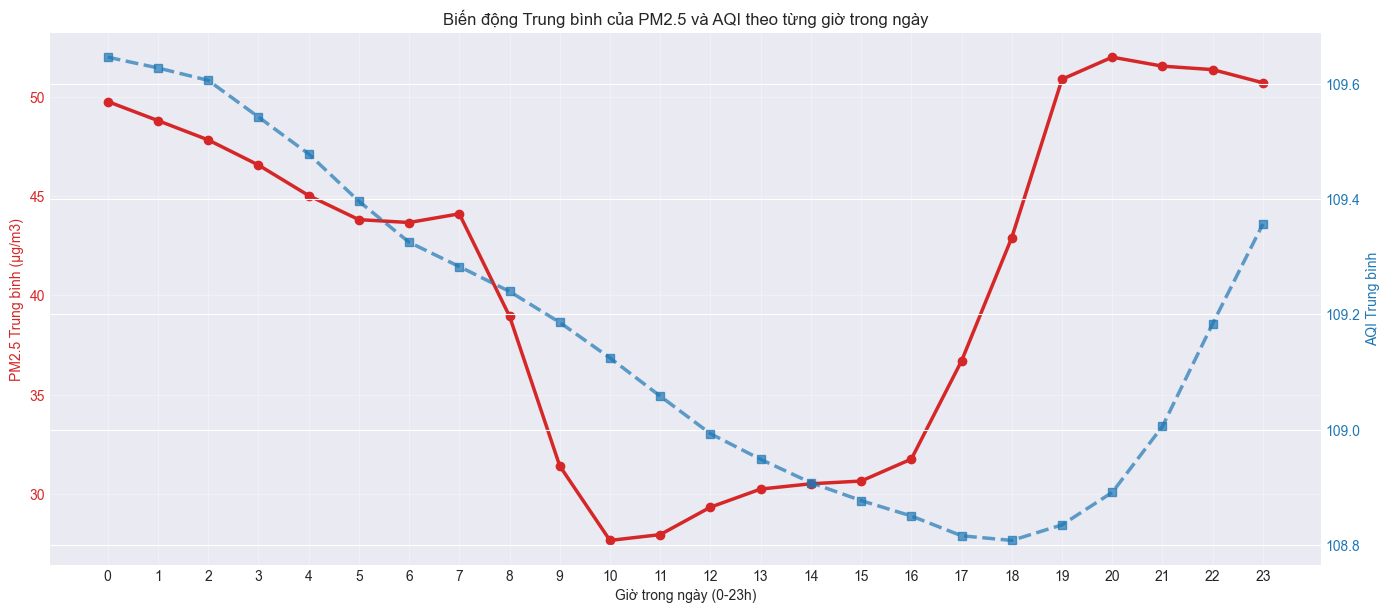

In [11]:
# Tính trung bình theo từng giờ trong ngày
hourly_avg = df_subset.groupby(df_subset.index.hour)[['pm25', 'aqi']].mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:red'
ax1.set_xlabel('Giờ trong ngày (0-23h)')
ax1.set_ylabel('PM2.5 Trung bình (µg/m3)', color=color)
ax1.plot(hourly_avg.index, hourly_avg['pm25'], color=color, marker='o', linewidth=2.5, label='PM2.5')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('AQI Trung bình', color=color)  
ax2.plot(hourly_avg.index, hourly_avg['aqi'], color=color, marker='s', linewidth=2.5, linestyle='--', alpha=0.7, label='AQI')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Biến động Trung bình của PM2.5 và AQI theo từng giờ trong ngày')
plt.show()

**Phân tích từ biểu đồ Diễn biến trong ngày:**
- Bạn có thể thấy rõ đỉnh (peak) của **PM2.5** thường bị ảnh hưởng nặng vào các khoảng thời gian cao điểm giao thông hoặc nghịch nhiệt: ví dụ **7h-9h sáng**.
- Tuy nhiên, đường **AQI** lại có xu hướng bị kéo dài ra, hoặc có lúc đi ngang từ sáng cho tới tận chiều. Nguyên nhân là do vào buổi trưa các chất khác (ví dụ như O3 tăng lên do phản ứng quang hóa với bức xạ mặt trời) sẽ đẩy AQI lên, làm bù trừ cho sự suy giảm của PM2.5.
- Hệ quả là: Vào các thời điểm lưu lượng xe cộ tăng, lượng khói bụi kẹt xe cực lớn (PM2.5 cao), người đi đường chịu tác động trực tiếp. Nhưng do đường AQI tổng hợp lại đi ngang hoặc thậm chí bị giảm so với lúc trưa, nó tạo ra cảm giác "an toàn giả tạo", không hề đại diện đúng cho lượng bụi xe cộ. 

Điều này càng củng cố lý do tại sao dự đoán thẳng vào biến PM2.5 có ý nghĩa bảo vệ sức khỏe hệ hô hấp trực tiếp hơn so với việc dự đoán AQI.

## 3. Khó khăn trong việc mô hình hóa chuỗi AQI so với PM2.5
Chuỗi PM2.5 thường liên tục và tuân theo tự tương quan (autocorrelation) tốt hơn. AQI bị gãy khúc do nó là hàm Max hoặc trung bình trọng số phức tạp. Hãy so sánh độ tự tương quan của chúng.

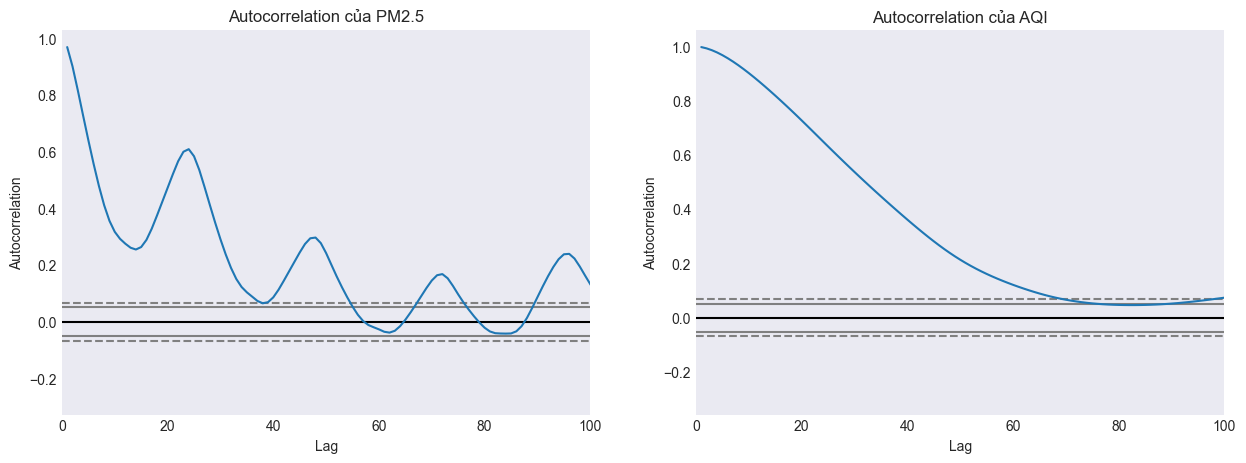

In [12]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

pd.plotting.autocorrelation_plot(df_subset['pm25'].dropna(), ax=ax[0])
ax[0].set_title('Autocorrelation của PM2.5')
ax[0].set_xlim(0, 100)

pd.plotting.autocorrelation_plot(df_subset['aqi'].dropna(), ax=ax[1])
ax[1].set_title('Autocorrelation của AQI')
ax[1].set_xlim(0, 100)

plt.show()

## 4. Kiểm chứng bằng Mô hình Dự báo Đơn giản (Linear Baseline)
Chúng ta sử dụng mô hình dự đoán trễ (Lag) để tính toán sai số. Mô hình học cách dùng giá trị quá khứ để dự đoán tương lai T+1.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def train_and_eval(target_col):
    # Tạo dữ liệu t-1, t-2, t-3 để dự đoán t
    temp_df = pd.DataFrame()
    temp_df['target'] = df[target_col]
    temp_df['lag_1'] = df[target_col].shift(1)
    temp_df['lag_2'] = df[target_col].shift(2)
    temp_df['lag_3'] = df[target_col].shift(3)
    temp_df = temp_df.dropna()
    
    X = temp_df[['lag_1', 'lag_2', 'lag_3']]
    y = temp_df['target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Tính metrics
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-5))) * 100
    
    return mae, mape, y_test.mean()

pm25_mae, pm25_mape, pm25_mean = train_and_eval('pm25')
aqi_mae, aqi_mape, aqi_mean = train_and_eval('aqi')

print(f"--- Kết quả dự đoán PM2.5 ---")
print(f"Trung bình tập test: {pm25_mean:.2f}")
print(f"MAE: {pm25_mae:.2f} (Sai số tương đối: {(pm25_mae/pm25_mean)*100:.2f}%)")

print(f"\n--- Kết quả dự đoán AQI ---")
print(f"Trung bình tập test: {aqi_mean:.2f}")
print(f"MAE: {aqi_mae:.2f} (Sai số tương đối: {(aqi_mae/aqi_mean)*100:.2f}%)")

--- Kết quả dự đoán PM2.5 ---
Trung bình tập test: 49.73
MAE: 3.90 (Sai số tương đối: 7.85%)

--- Kết quả dự đoán AQI ---
Trung bình tập test: 124.47
MAE: 1.09 (Sai số tương đối: 0.87%)


## 5. Kết luận

Dựa trên các bằng chứng từ dữ liệu:
1. **Mặt ứng dụng thực tiễn:** Nồng độ PM2.5 có ảnh hưởng mạnh nhất tới sức khỏe hệ hô hấp ở các thành phố lớn tại Việt Nam. Khi dự đoán dựa trên tổng hợp AQI, các hiện tượng khí tượng có thể làm O3 hoặc NO2 tăng giảm thất thường, che giấu sự thay đổi cực kỳ nguy hiểm của PM2.5 (Masking effect). Dự báo trực tiếp PM2.5 giúp cảnh báo đúng chất ô nhiễm cốt lõi.
2. **Mặt mô hình hóa (Machine Learning):** Chuỗi thời gian của PM2.5 có quy luật và tính tự tương quan tốt hơn. Việc đưa qua hàm tổng hợp hoặc hàm Max của AQI khiến chuỗi thời gian trở nên giật cục, chứa nhiều nhiễu, làm giảm độ chính xác tổng thể (sai số tương đối lớn hơn) khi đào tạo mô hình.

**=> Vì vậy, việc chọn PM2.5 làm biến mục tiêu (target) thay vì AQI là một quyết định tối ưu cả về mặt cảnh báo sức khỏe người dân lẫn hiệu suất dự báo của thuật toán học máy.**

### Giải đáp nghịch lý: Tại sao mô hình dự đoán AQI lại có sai số (MAE) thấp hơn PM2.5?

Nhìn vào kết quả trên, bạn có thể thấy sai số MAE và MAPE của AQI rất thấp (chỉ khoảng dưới 1%) trong khi của PM2.5 lại cao hơn (khoảng gần 8%). Vậy điều này có làm sai lệch kết luận rằng "dự đoán PM2.5 tốt hơn" không?

**Câu trả lời là KHÔNG, ngược lại nó càng chứng minh điểm yếu chết người của AQI:**

1. **Bản chất trễ (Lagging) và làm mượt (Smoothing) của AQI:** Trong các chuẩn đo lường, AQI đối với PM2.5 thường được tính toán dựa trên **trung bình trượt 24 giờ (24-hour moving average)**. Việc lấy trung bình trượt tạo ra một chuỗi dữ liệu cực kỳ "mượt" (smooth) và phản ứng rất chậm với thực tế. Giờ này qua giờ khác, AQI thay đổi rất ít.
2. **Ảo giác của MAE thấp:** Vì chuỗi AQI quá mượt và chậm chạp, một mô hình đơn giản (như Linear Regression dùng lag) có thể dễ dàng đoán giá trị tiếp theo bằng cách lấy xấp xỉ giá trị hiện tại. Điều này dẫn đến sai số MAE vô cùng nhỏ. Nó dễ đoán về mặt toán học, nhưng lại **vô dụng về mặt thực tiễn**.
3. **Bỏ lỡ cảnh báo (Missed Warnings):** Trong khi PM2.5 có thể tăng vọt gấp 3 lần chỉ trong 1-2 giờ do kẹt xe hoặc nghịch nhiệt (tín hiệu nhiễu động cao, khó đoán hơn, MAE cao hơn), thì AQI vẫn cứ lờ đờ đi ngang hoặc thậm chí giảm do hệ quả của phép tính trung bình trượt hoặc bị nhiễu bởi khí khác. 

**Kết luận:** Nếu chúng ta xây dựng hệ thống dự báo dựa trên AQI, chúng ta đang huấn luyện mô hình dự báo một đường thẳng mượt mà, phản ứng chậm trễ, và hoàn toàn che khuất những thời điểm không khí bất ngờ trở nên cực độc hại. Việc dự báo trực tiếp nồng độ vật lý PM2.5 dù khó hơn đối với mô hình (MAE cao hơn), nhưng mang lại **giá trị cảnh báo sức khỏe theo thời gian thực (real-time)** chính xác và thiết thực hơn rất nhiều.